# 数据拟合的 Python 实现
1. Numpy库多项式拟合函数 polyfit（Polynomial Fit多项式拟合）
2. scipy.optimize模块的函数 leastsq（Least Squares最小二乘法）, curve_fit

### 1. polyfit 的用法

np.polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)

| 参数     | 说明                                                                 |
|----------|----------------------------------------------------------------------|
| `x`      | 自变量数组（如横坐标）                                               |
| `y`      | 因变量数组（如纵坐标）                                               |
| `deg`    | 多项式的阶数，例如 `1` 表示线性拟合，`2` 表示二次拟合等              |
| `rcond`  | 拟合的条件数，默认值通常不需要更改（控制数值稳定性）                  |
| `full`   | 是否返回完整的拟合信息，设为 `True` 会返回更多详细结果               |
| `w`      | 权重数组，用于加权拟合                                               |
| `cov`    | 是否返回协方差矩阵，适用于评估拟合参数的可靠性                        |


拟合二次多项式的从高次幂到低次幂系数分别为：
[-9.81083916 20.12929371 -0.03167133]
拟合点0.25, 0.35的预测值值为：[4.38747465 5.81175367]


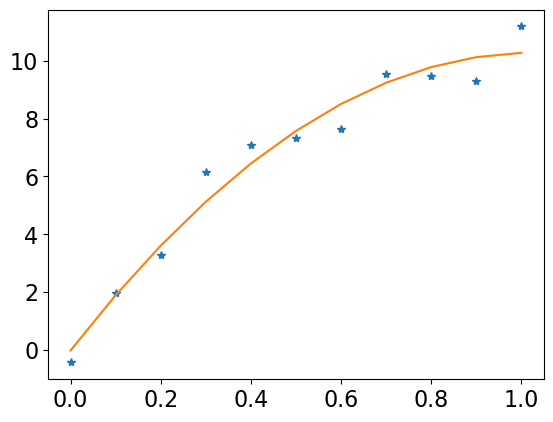

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x0 = np.arange(0, 1.1, 0.1)
y0 = np.array([-0.447, 1.978, 3.28, 6.16, 7.08, 7.34, 7.66, 9.56, 9.48, 9.30, 11.2])
p = np.polyfit(x0, y0, 2)  # 二次多项式拟合
print(f"拟合二次多项式的从高次幂到低次幂系数分别为：\n{p}")
yhat = np.polyval(p, [0.25, 0.35])
print(f"拟合点0.25, 0.35的预测值值为：{yhat}")

plt.rcParams['font.size'] = '16'
plt.plot(x0, y0, '*', x0, np.polyval(p, x0), '-')
plt.show()


### 2. curve_fit 的用法

curve_fit 的调用格式为  
popt, pcov = curve_fit(func, xdata, ydata)

其中 func 是拟合的函数，xdata 是自变量的观测值，ydata 是函数的观测值，返回值 popt 是拟合的参数，pcov 是参数的协方差矩阵.

拟合的参数值为：[-9.81083901 20.12929291 -0.03167108]
预测的值分别为：[4.38747471 5.81175366]


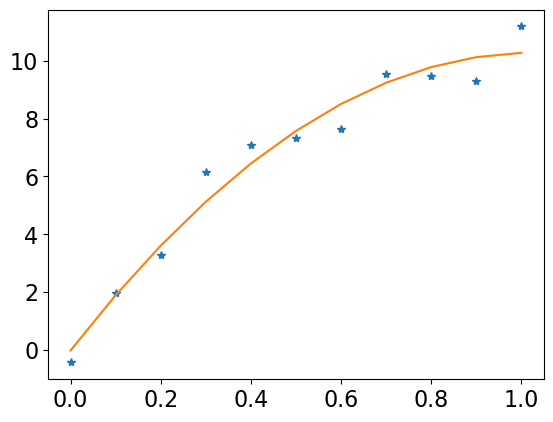

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

y = lambda x, a, b, c: a*x**2 + b*x + c  # 定义拟合函数
xdata = np.arange(0, 1.1, 0.1)
ydata = np.array([-0.447, 1.978, 3.28, 6.16, 7.08, 7.34, 7.66, 9.56, 9.48, 9.30, 11.2])
popt, pcov = curve_fit(y, xdata, ydata)  # curve_fit 返回拟合参数和协方差矩阵

print(f"拟合的参数值为：{popt}")
print(f"预测的值分别为：{y(np.array([0.25, 0.35]), *popt)}")

plt.rcParams['font.size'] = '16'
plt.plot(xdata, ydata, '*', xdata, y(xdata, *popt), '-')
plt.show()


使用表 7.6 中的数据来拟合以下形式的复合函数：

$$
z = ae^{bx} + cy^2
$$

表 7.6 的观测数据如下：

| \(x\) | 6 | 2 | 6 | 7 | 4 | 2 | 5 | 9 |
|------|---|---|---|---|---|---|---|---|
| \(y\) | 4 | 9 | 5 | 3 | 8 | 5 | 8 | 2 |
| \(z\) | 5 | 2 | 1 | 9 | 7 | 4 | 3 | 3 |

a, b, c 的拟合值为：[ 5.08907305e+00 -2.58248004e-03 -2.14509683e-02]


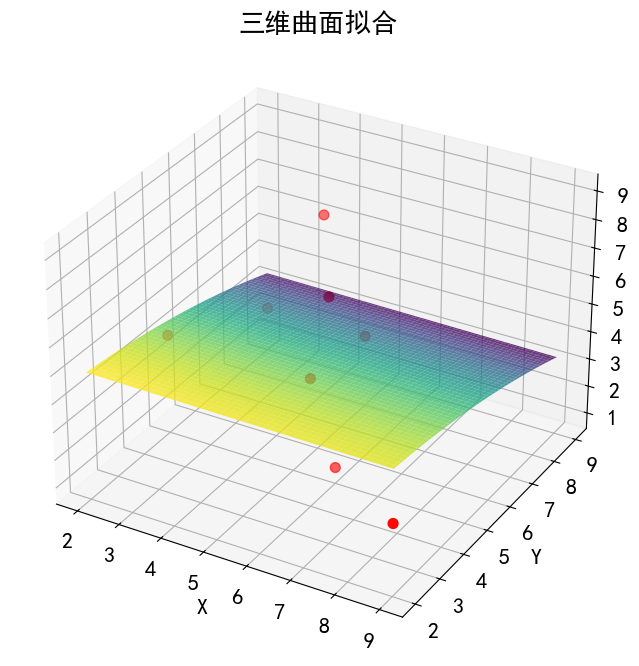

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

x0 = np.array([6, 2, 6, 7, 4, 2, 5, 9])
y0 = np.array([4, 9, 5, 3, 8, 5, 8, 2])
z0 = np.array([5, 2, 1, 9, 7, 4, 3, 3])
xy0 = np.vstack((x0, y0))

def Pfun(t, a, b, c):
    return a * np.exp(b * t[0]) + c * t[1]**2

popt, pcov = curve_fit(Pfun, xy0, z0)  # curve_fit 返回拟合参数和协方差矩阵
print(f"a, b, c 的拟合值为：{popt}")

x_grid = np.linspace(x0.min(), x0.max(), 100)
y_grid = np.linspace(y0.min(), y0.max(), 100)
x_mesh, y_mesh = np.meshgrid(x_grid, y_grid)
# ravel() 将二维数组展平为一维数组
# vstack() 将多个一维数组按行堆叠成二维数组
t_mesh = np.vstack((x_mesh.ravel(), y_mesh.ravel()))
z_mesh = Pfun(t_mesh, *popt).reshape(x_mesh.shape)

plt.rcParams['font.size'] = '16'
plt.rcParams['font.family'] = 'SimHei'
plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot_surface(x_mesh, y_mesh, z_mesh, cmap='viridis', alpha=0.8)
ax.scatter(x0, y0, z0, color='r', s=50)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('三维曲面拟合')
plt.savefig('3d_surface_fit.png')
plt.show()

我们使用以下函数形式拟合一个曲面：

$$
z = e^{-\frac{(x - \mu_1)^2 + (y - \mu_2)^2}{2\sigma^2}}
$$

其中参数初始值为：
- $\mu_1 = 1$
- $\mu_2 = 2$
- $\sigma = 3$

我们将基于该函数生成带有噪声的模拟数据，并拟合上述参数，再画出拟合得到的曲面图形。

拟合的参数值为：[1.01552456 2.00700225 2.99481582]


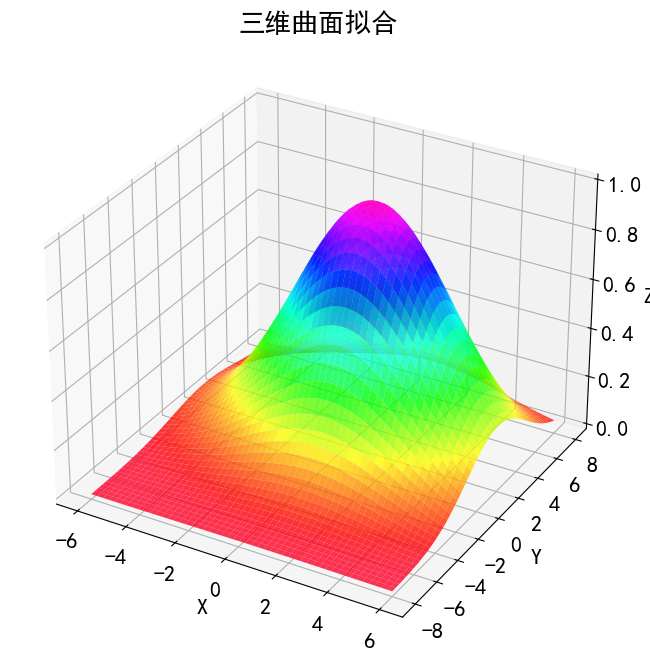

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D

m = 200
n = 300
x = np.linspace(-6, 6, m)
y = np.linspace(-8, 8, n)
x2, y2 = np.meshgrid(x, y)
x3 = np.reshape(x2, (1, -1))  # 将二维数组转换为一维数组
y3 = np.reshape(y2, (1, -1))  # 将二维数组转换为一维数组
xy = np.vstack((x3, y3))

def Pfun(t, m1, m2, s):
    return np.exp(-((t[0] - m1)**2 + (t[1] - m2)**2) / (2 * s**2))

z = Pfun(xy, 1, 2, 3)
zr = z + 0.2 * np.random.normal(size=z.shape)  # 添加噪声
popt, pcov = curve_fit(Pfun, xy, zr)
print(f"拟合的参数值为：{popt}")

zn = Pfun(xy, *popt)  # 计算拟合函数的值
zn2 = np.reshape(zn, x2.shape) # 将一维数组转换为二维数组

plt.rcParams['font.size'] = '16'
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False 

plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')  # 创建三维坐标轴对象
ax.plot_surface(x2, y2, zn2, cmap='gist_rainbow', alpha=0.8)  # 绘制三维曲面
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('三维曲面拟合')
plt.savefig("三维曲面拟合.png", dpi=500)
plt.show()